## Syntetic Control

In [95]:
import polars as pl
import numpy as np
import pandas as pd

### Online Marketing Dataset

In [96]:
df = (
    pl.read_csv("../data/online_mkt.csv")
      .with_columns(
        pl.col("date").str.to_date()
      )
)
df

app_download,population,city,state,date,post,treated
f64,i64,str,str,date,i64,i64
3066.0,12396372,"""sao_paulo""","""sao_paulo""",2022-03-01,0,1
2701.0,12396372,"""sao_paulo""","""sao_paulo""",2022-03-02,0,1
1927.0,12396372,"""sao_paulo""","""sao_paulo""",2022-03-03,0,1
1451.0,12396372,"""sao_paulo""","""sao_paulo""",2022-03-04,0,1
1248.0,12396372,"""sao_paulo""","""sao_paulo""",2022-03-05,0,1
…,…,…,…,…,…,…
99.0,481725,"""maua""","""sao_paulo""",2022-06-26,1,0
233.0,481725,"""maua""","""sao_paulo""",2022-06-27,1,0
241.0,481725,"""maua""","""sao_paulo""",2022-06-28,1,0


In [97]:
treated = df.filter(pl.col("treated") == 1).select("city").unique()
treated = treated.to_series().to_list()
treated

['porto_alegre', 'joao_pessoa', 'sao_paulo']

Puede ser complejo manejar a ciudades enormes como por ejemplo **Sao Paolo** que tiene una catidad enorme de habitantes
ya que como es de las más grandes del mundo, con más habitantes, asemejarse a la misma es complejo.

In [98]:
df_norm = df.with_columns(
    app_download_pct = (pl.col("app_download") / pl.col("population")) * 100
)
df_norm

app_download,population,city,state,date,post,treated,app_download_pct
f64,i64,str,str,date,i64,i64,f64
3066.0,12396372,"""sao_paulo""","""sao_paulo""",2022-03-01,0,1,0.024733
2701.0,12396372,"""sao_paulo""","""sao_paulo""",2022-03-02,0,1,0.021789
1927.0,12396372,"""sao_paulo""","""sao_paulo""",2022-03-03,0,1,0.015545
1451.0,12396372,"""sao_paulo""","""sao_paulo""",2022-03-04,0,1,0.011705
1248.0,12396372,"""sao_paulo""","""sao_paulo""",2022-03-05,0,1,0.010067
…,…,…,…,…,…,…,…
99.0,481725,"""maua""","""sao_paulo""",2022-06-26,1,0,0.020551
233.0,481725,"""maua""","""sao_paulo""",2022-06-27,1,0,0.048368
241.0,481725,"""maua""","""sao_paulo""",2022-06-28,1,0,0.050029


Nos damos cuenta de que el tratamiento en las ciudades comenzo en 2022-05-01

In [99]:
tr_period = df_norm.filter(pl.col("post") == 1).select(pl.col("date").min()).item()
tr_period

datetime.date(2022, 5, 1)

## 1. Las Variables Principales

- **$D_i$ (Tratamiento):** Indica si una unidad $i$ (ciudad, estado, empresa) pertenece al grupo que recibirá el tratamiento. Es una variable fija para esa unidad:  
    Si, por ejemplo, California es tratada, entonces $D_{\text{California}} = 1$ siempre.

- **$t$ (Tiempo):** Es el reloj del experimento, es decir, el índice temporal (días, meses, años).

- **$T$ (Total):** El número total de periodos que tienes en tus datos.

---

## 2. La Línea de Tiempo del Experimento

El tiempo se divide en dos bloques críticos:

- **$T_{pre}$:** El periodo de "entrenamiento" o pre-intervención. Aquí es donde el Control Sintético intenta copiar el comportamiento de la unidad tratada.
- **$T_{post}$:** El periodo después de la intervención, donde medimos el impacto.

**Momento del impacto:**  
El tratamiento ocurre formalmente solo cuando se cumplen dos condiciones:  
- La unidad es del grupo tratado ($D=1$)
- El tiempo es posterior a la intervención ($t > T_{pre}$)

---

## 3. La Variable de Interacción ($W_{it}$)

Esta es la variable que realmente "enciende" el efecto en los modelos:

$$
W_{it} = D_i \times Post_t
$$

- Si estás en el pasado ($t < T_{pre}$), $Post_t = 0$, por lo que $W_{it} = 0$.
- Si eres una unidad de control ($D=0$), $W_{it}$ siempre es 0.
- $W_{it} = 1$ **solo** para la unidad tratada durante el periodo de impacto.


Ciudades encontradas: ['porto_alegre', 'joao_pessoa', 'sao_paulo']


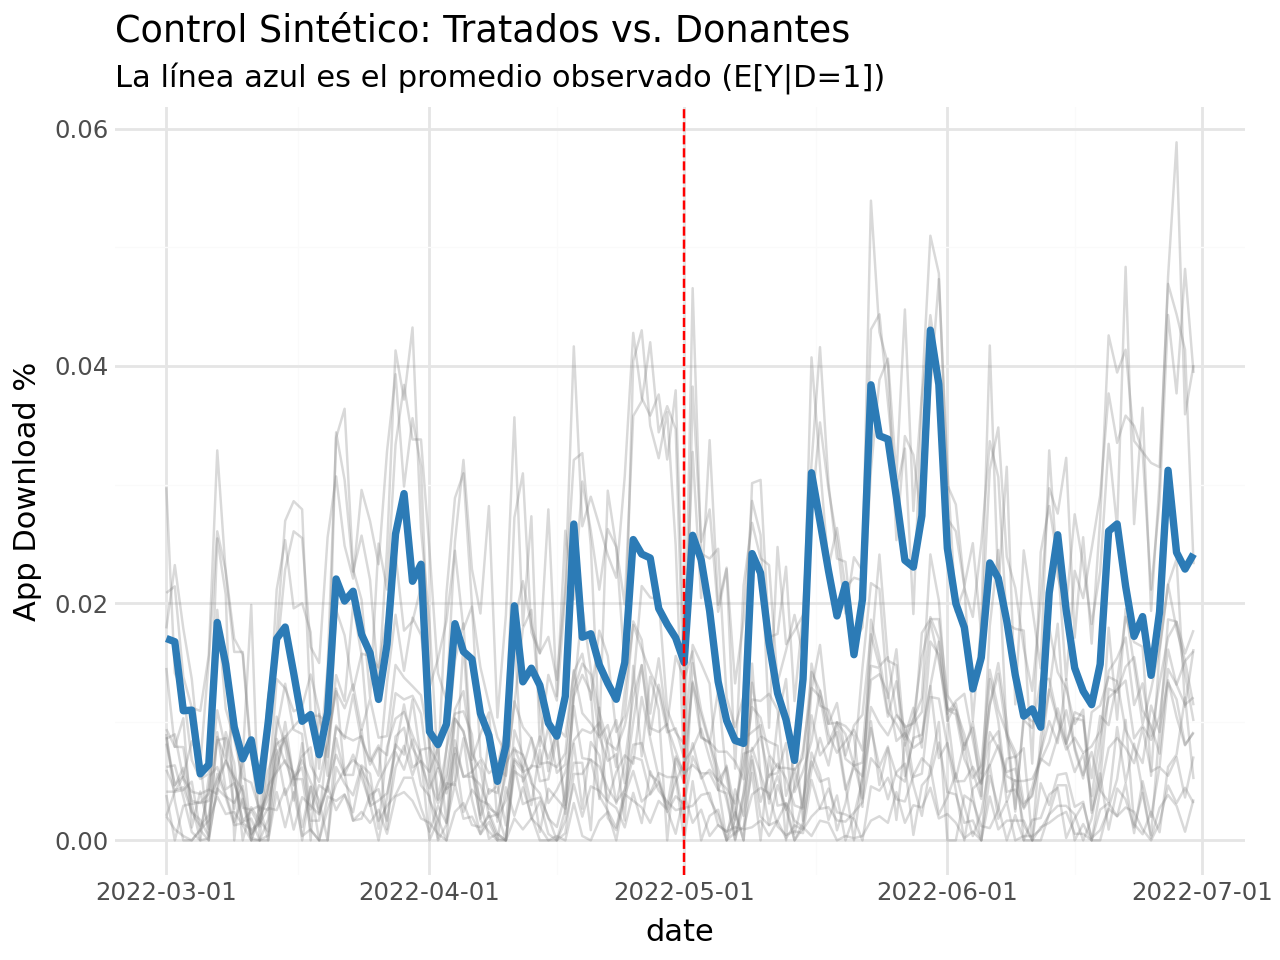

In [100]:

from plotnine import *
import random


treated_clean = treated

# 1. Preparar DataFrame (Pivot)
df_sc = (
    df_norm
    .with_columns(pl.col("city").cast(pl.String).str.to_lowercase().str.strip_chars())
    .pivot(values="app_download_pct", index="date", on="city")
    .sort("date")
)

# 2. Intersección (Ahora sí funcionará porque son strings puros)
treated_cols = list(set(df_sc.columns) & set(treated_clean))

# Verificación visual
print(f"Ciudades encontradas: {treated_cols}")

# 3. Preparar datos para el gráfico
# A: Promedio Tratados
df_mean = df_sc.select(pl.col("date"), pl.mean_horizontal(treated_cols).alias("value"))

# B: Controles (Donantes)
control_cols = list(set(df_sc.columns) - set(treated_cols) - {"date"})
sample_n = min(len(control_cols), 15)

random.seed(123)
df_bg = df_sc.select("date", *random.sample(control_cols, sample_n)).unpivot(
    index="date", variable_name="city", value_name="value"
)

# 4. Gráfico
(
    ggplot()
    + geom_line(df_bg, aes("date", "value", group="city"), color="gray", alpha=0.3)
    + geom_line(df_mean, aes("date", "value"), color="#2c7bb6", size=1.5)
    + geom_vline(xintercept=pd.to_datetime(tr_period), linetype="dashed", color="red")
    + labs(
        title="Control Sintético: Tratados vs. Donantes",
        subtitle="La línea azul es el promedio observado (E[Y|D=1])",
        y="App Download %"
    )
    + theme_minimal()
)

## Matrix Representation

El syntetic control se puede representar como una matriz donde las filas son las unidades (ciudades) y las columnas son los periodos de tiempo. En esta matriz, el tratamiento se refleja en la columna correspondiente al periodo post-intervención para la unidad tratada.

con la siguiente fórmula de matriz (usando notación matemática para mayor claridad):

$$
W = 
\begin{bmatrix}
0_{\text{pre, co}} & 0_{\text{pre, tr}} \\
0_{\text{post, co}} & 1_{\text{post, tr}}
\end{bmatrix}
$$

Esta matriz de asignación genera la siguiente matriz de resultados potenciales observados:

$$
Y = 
\begin{bmatrix}
Y^{0}_{\text{pre, co}} & Y^{0}_{\text{pre, tr}} \\
Y^{0}_{\text{post, co}} & Y^{1}_{\text{post, tr}}
\end{bmatrix}
$$

In [101]:
import polars as pl

def reshape_sc_data(df: pl.DataFrame, 
                    geo_col: str, 
                    time_col: str, 
                    y_col: str, 
                    tr_geos: list[str], 
                    tr_start_st: str):
    
    # 1. Pivotar y Ordenar
    df_pivot = (
        df.pivot(values=y_col, index=time_col, on=geo_col)
        .sort(time_col)
    )

    # 2. Filtrar fechas
    # Convertimos el string a fecha para comparar correctamente
    cutoff_date = pl.lit(tr_start_st).str.to_date()
    
    df_pre = df_pivot.filter(pl.col(time_col) < cutoff_date)
    df_post = df_pivot.filter(pl.col(time_col) >= cutoff_date)

    # 3. Separar Matrices (CORRECCIÓN AQUÍ)
    
    # TRATADOS (Y1): Queremos [Fecha, Ciudad1, Ciudad2...]
    # Sumamos la lista [time_col] con la lista tr_geos
    cols_tr = [time_col] + tr_geos
    y_pre_tr = df_pre.select(cols_tr)
    y_post_tr = df_post.select(cols_tr)

    # CONTROLES (X0): Queremos [Fecha, Resto_de_ciudades...]
    # Excluimos SOLO las ciudades tratadas, así la fecha se queda
    y_pre_co = df_pre.select(pl.exclude(tr_geos))
    y_post_co = df_post.select(pl.exclude(tr_geos))

    return y_pre_co, y_pre_tr, y_post_co, y_post_tr



In [102]:
# --- Ejecución ---
treated_clean = ["porto_alegre", "joao_pessoa", "sao_paulo"]

y_pre_co, y_pre_tr, y_post_co, y_post_tr = reshape_sc_data(
    df=df_norm,  
    geo_col="city", 
    time_col="date", 
    y_col="app_download_pct", 
    tr_geos=treated_clean, 
    tr_start_st=str(tr_period)
)

# Verificamos que ahora sí tenga la fecha
print(y_pre_tr.head())

shape: (5, 4)
┌────────────┬──────────────┬─────────────┬───────────┐
│ date       ┆ porto_alegre ┆ joao_pessoa ┆ sao_paulo │
│ ---        ┆ ---          ┆ ---         ┆ ---       │
│ date       ┆ f64          ┆ f64         ┆ f64       │
╞════════════╪══════════════╪═════════════╪═══════════╡
│ 2022-03-01 ┆ 0.004288     ┆ 0.022039    ┆ 0.024733  │
│ 2022-03-02 ┆ 0.008107     ┆ 0.020344    ┆ 0.021789  │
│ 2022-03-03 ┆ 0.004891     ┆ 0.012352    ┆ 0.015545  │
│ 2022-03-04 ┆ 0.002948     ┆ 0.018285    ┆ 0.011705  │
│ 2022-03-05 ┆ 0.006767     ┆ 0.0         ┆ 0.010067  │
└────────────┴──────────────┴─────────────┴───────────┘


## Syntetic Control as Horizontal Regression

In [103]:
from sklearn.linear_model import LinearRegression

model = LinearRegression(fit_intercept=False)  # Sin intercepto para forzar la combinación convexa
model.fit(y_pre_co.drop("date").to_pandas(), y_pre_tr.drop("date").to_pandas().mean(axis=1))  # Ajustamos con el promedio de los tratados

# extract weights
weights_lr = model.coef_
weights_lr.round(3)

array([ 0.429,  0.007,  0.23 ,  0.132, -0.204,  0.158, -0.5  ,  0.089,
        0.115,  0.971,  0.094,  0.095,  0.128,  0.351, -0.11 , -0.041,
        0.102,  0.036,  0.147,  0.098, -0.066, -0.128, -0.086, -0.057,
        0.151,  0.555,  0.024,  0.088,  0.079, -0.239, -0.154,  0.032,
       -0.058, -0.058,  0.049, -0.353, -0.047, -0.65 , -0.205,  0.074,
       -0.476, -0.129, -0.014,  0.03 ,  0.106,  0.229, -0.002])

In [104]:
y_pre_tr.drop("date").to_pandas().mean(axis=1)

0    1.70e-02
1    1.67e-02
2    1.09e-02
3    1.10e-02
4    5.61e-03
       ...   
56   2.41e-02
57   2.38e-02
58   1.95e-02
59   1.82e-02
60   1.71e-02
Length: 61, dtype: float64

Teniendo los pesos se puede pasa a calcular la estimación de $Y^0_{\text{post, tr}}$ como una combinación lineal de las unidades de control:
$$
\hat{Y}^0_{\text{post, tr}} = \sum_{i \in \text{control}} w_i Y^0_{\text{post, i}}
$$

In [105]:
y0_tr_hat = y_post_co.drop("date").to_pandas().dot(weights_lr)
y0_tr_hat[:]

0    1.34e-02
1    1.87e-02
2    1.68e-02
3    1.47e-02
4    1.24e-02
       ...   
56   2.00e-02
57   2.98e-02
58   2.42e-02
59   2.83e-02
60   2.91e-02
Length: 61, dtype: float64

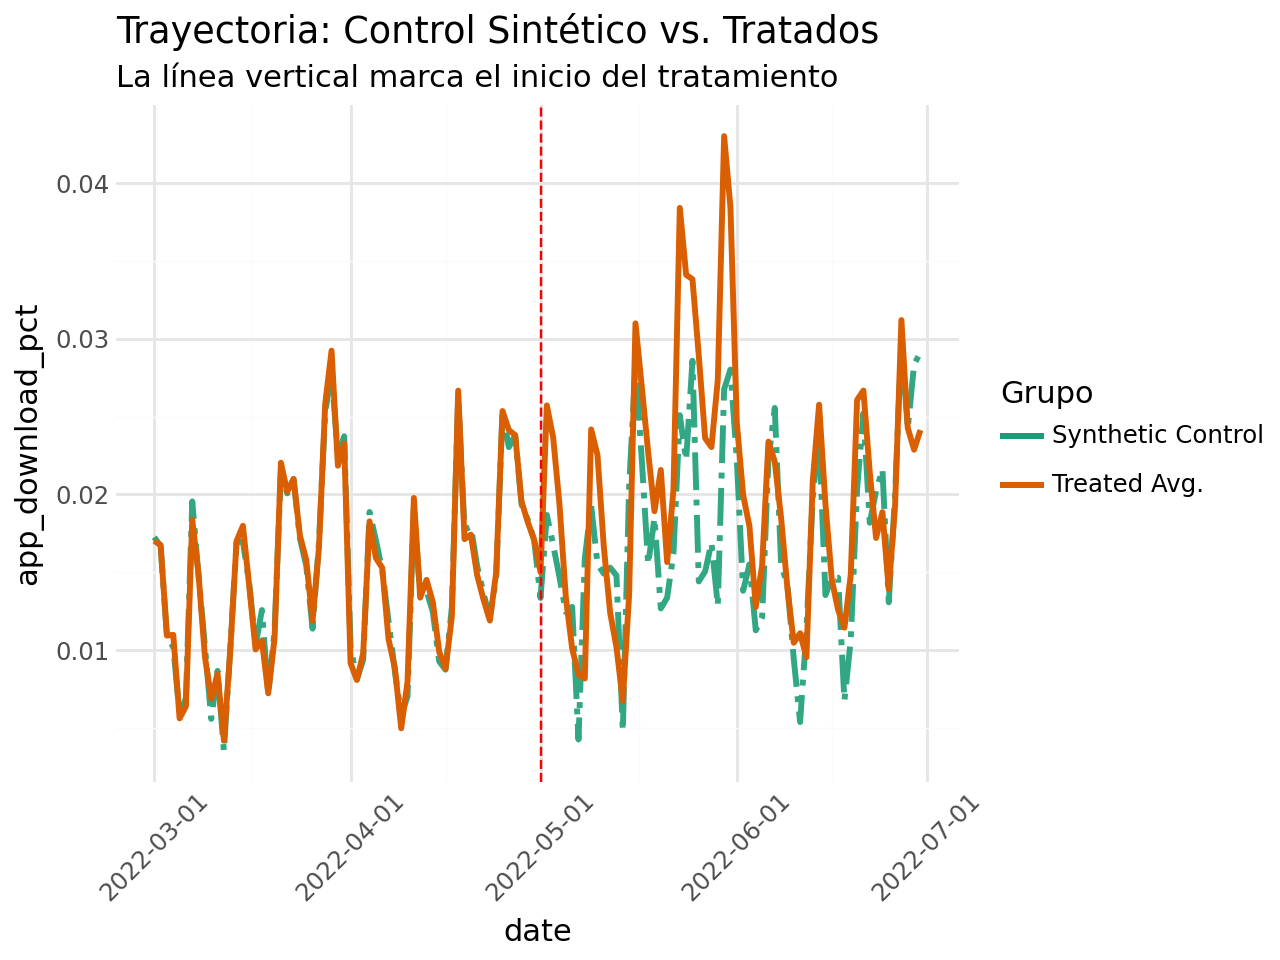

In [106]:
# 1. Concatenamos los periodos pre y post para controles y tratados
df_controls_all = pl.concat([y_pre_co, y_post_co])
df_treated_all = pl.concat([y_pre_tr, y_post_tr])

# 2. Calculamos la predicción sintética usando el modelo entrenado
synthetic = model.predict(df_controls_all.drop("date").to_pandas())

# 3. Calculamos el promedio de los tratados reales
treated_avg = df_treated_all.drop("date").to_pandas().mean(axis=1)

# 4. Armamos el DataFrame final en Polars y luego lo pasamos a pandas para plotnine
df_plot = pl.DataFrame({
    "date": df_controls_all["date"],
    "synthetic": synthetic,
    "treated_avg": treated_avg
})

# 5. Graficamos
from plotnine import *

(
    ggplot(df_plot, aes(x="date"))
    # Mapeamos el nombre del grupo al color dentro de aes() para generar la leyenda
    + geom_line(aes(y="synthetic", color="'Synthetic Control'"), linetype="dashdot", size=1.2, alpha=0.9)
    + geom_line(aes(y="treated_avg", color="'Treated Avg.'"), size=1.2)
    + geom_vline(xintercept=pd.to_datetime(tr_period), linetype="dashed", color="red")
    # Definimos los colores manualmente para cada etiqueta definida arriba
    + scale_color_manual(
        name="Grupo",
        values={"Synthetic Control": "#1b9e77", "Treated Avg.": "#d95f02"}
    )
    + labs(
        y="app_download_pct",
        title="Trayectoria: Control Sintético vs. Tratados",
        subtitle="La línea vertical marca el inicio del tratamiento"
    )
    + theme_minimal()
    + theme(axis_text_x=element_text(rotation=45))
)


In [107]:
att = y_post_tr.drop("date").to_pandas().mean() - y0_tr_hat.mean()
att

porto_alegre   -7.73e-03
joao_pessoa     1.29e-03
sao_paulo       1.53e-02
dtype: float64

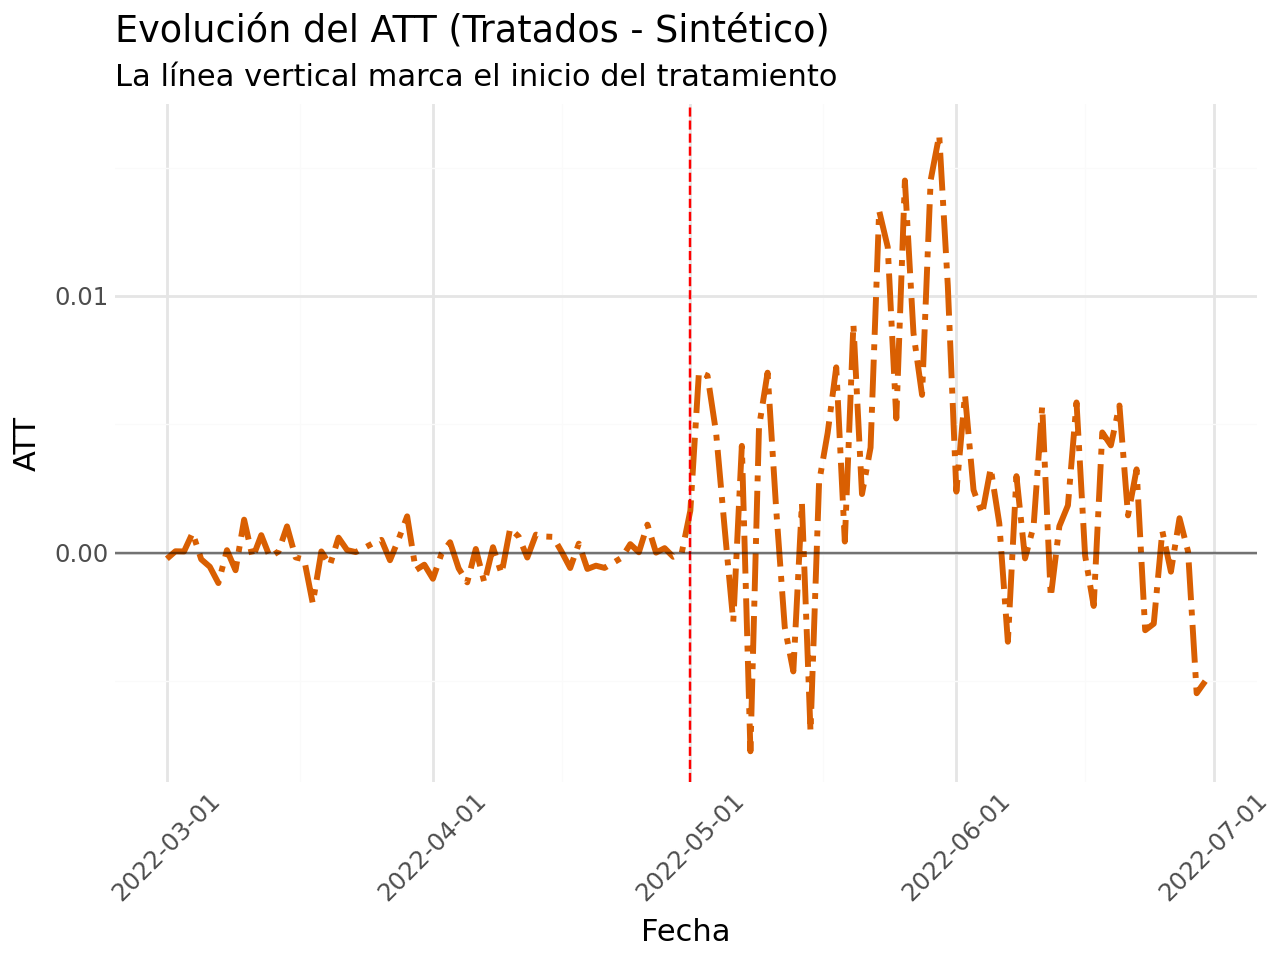

In [108]:
from plotnine import *

# Calculamos el ATT para cada fecha
df_plot = df_plot.with_columns(
    ATT = pl.col("treated_avg") - pl.col("synthetic")
)

# Creamos el gráfico
(
    ggplot(df_plot, aes(x="date", y="ATT"))
    + geom_line(linetype="dashdot", color="#d95f02", size=1.2)
    + geom_vline(xintercept=pd.to_datetime(tr_period), linetype="dashed", color="red", show_legend=True)
    + geom_hline(yintercept=0, linetype="solid", color="black", alpha=0.5)
    + labs(
        title="Evolución del ATT (Tratados - Sintético)",
        subtitle="La línea vertical marca el inicio del tratamiento",
        y="ATT",
        x="Fecha"
    )
    + theme_minimal()
    + theme(axis_text_x=element_text(rotation=45))
)

## Canonical Synthetic Control


In [109]:
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.utils.validation import check_X_y, check_array, check_is_fitted
import cvxpy as cp

class SyntheticControl(BaseEstimator, RegressorMixin):
    def __init__(self,):
        pass

    def fit(self, y_pre_co, y_pre_tr):
        y_pre_co, y_pre_tr = check_X_y(y_pre_co, y_pre_tr)

        w = cp.Variable(y_pre_co.shape[1])

        objective = cp.Minimize(cp.sum_squares(y_pre_co@w - y_pre_tr))
        constraints = [cp.sum(w) == 1, w >= 0]

        problem = cp.Problem(objective, constraints)

        self.loss_ = problem.solve(verbose=False)
        self.w_ = w.value

        self.is_fitted_ = True
        return self


    def predict(self, y_co):
        check_is_fitted(self)
        y_co = check_array(y_co)

        return y_co @ self.w_


In [110]:
model = SyntheticControl()
model.fit(y_pre_co.drop("date").to_pandas(), y_pre_tr.drop("date").to_pandas().mean(axis=1))

SyntheticControl()

In [111]:
# extrac the weights

model.w_.round(3)


array([ 0.046,  0.076,  0.089,  0.123, -0.   , -0.   , -0.   , -0.   ,
        0.008, -0.   ,  0.074,  0.037, -0.   ,  0.061, -0.   , -0.   ,
        0.083, -0.   ,  0.   ,  0.067, -0.   ,  0.   ,  0.   ,  0.   ,
       -0.   ,  0.086,  0.092,  0.088, -0.   , -0.   , -0.   , -0.   ,
        0.   , -0.   , -0.   , -0.   , -0.   , -0.   , -0.   , -0.   ,
       -0.   ,  0.   ,  0.061, -0.   ,  0.01 , -0.   , -0.   ])

In [112]:
# same as y0_tr_hat = model.predict(y_post_co)
y0_tr_hat = y_post_co.drop("date").to_pandas().dot(weights_lr)
y0_tr_hat[:]

0    1.34e-02
1    1.87e-02
2    1.68e-02
3    1.47e-02
4    1.24e-02
       ...   
56   2.00e-02
57   2.98e-02
58   2.42e-02
59   2.83e-02
60   2.91e-02
Length: 61, dtype: float64

In [113]:
df_plot = pl.DataFrame({
    "date": df_controls_all["date"],
    "synthetic": model.predict(df_controls_all.drop("date").to_pandas()),
    "treated_avg": treated_avg
})


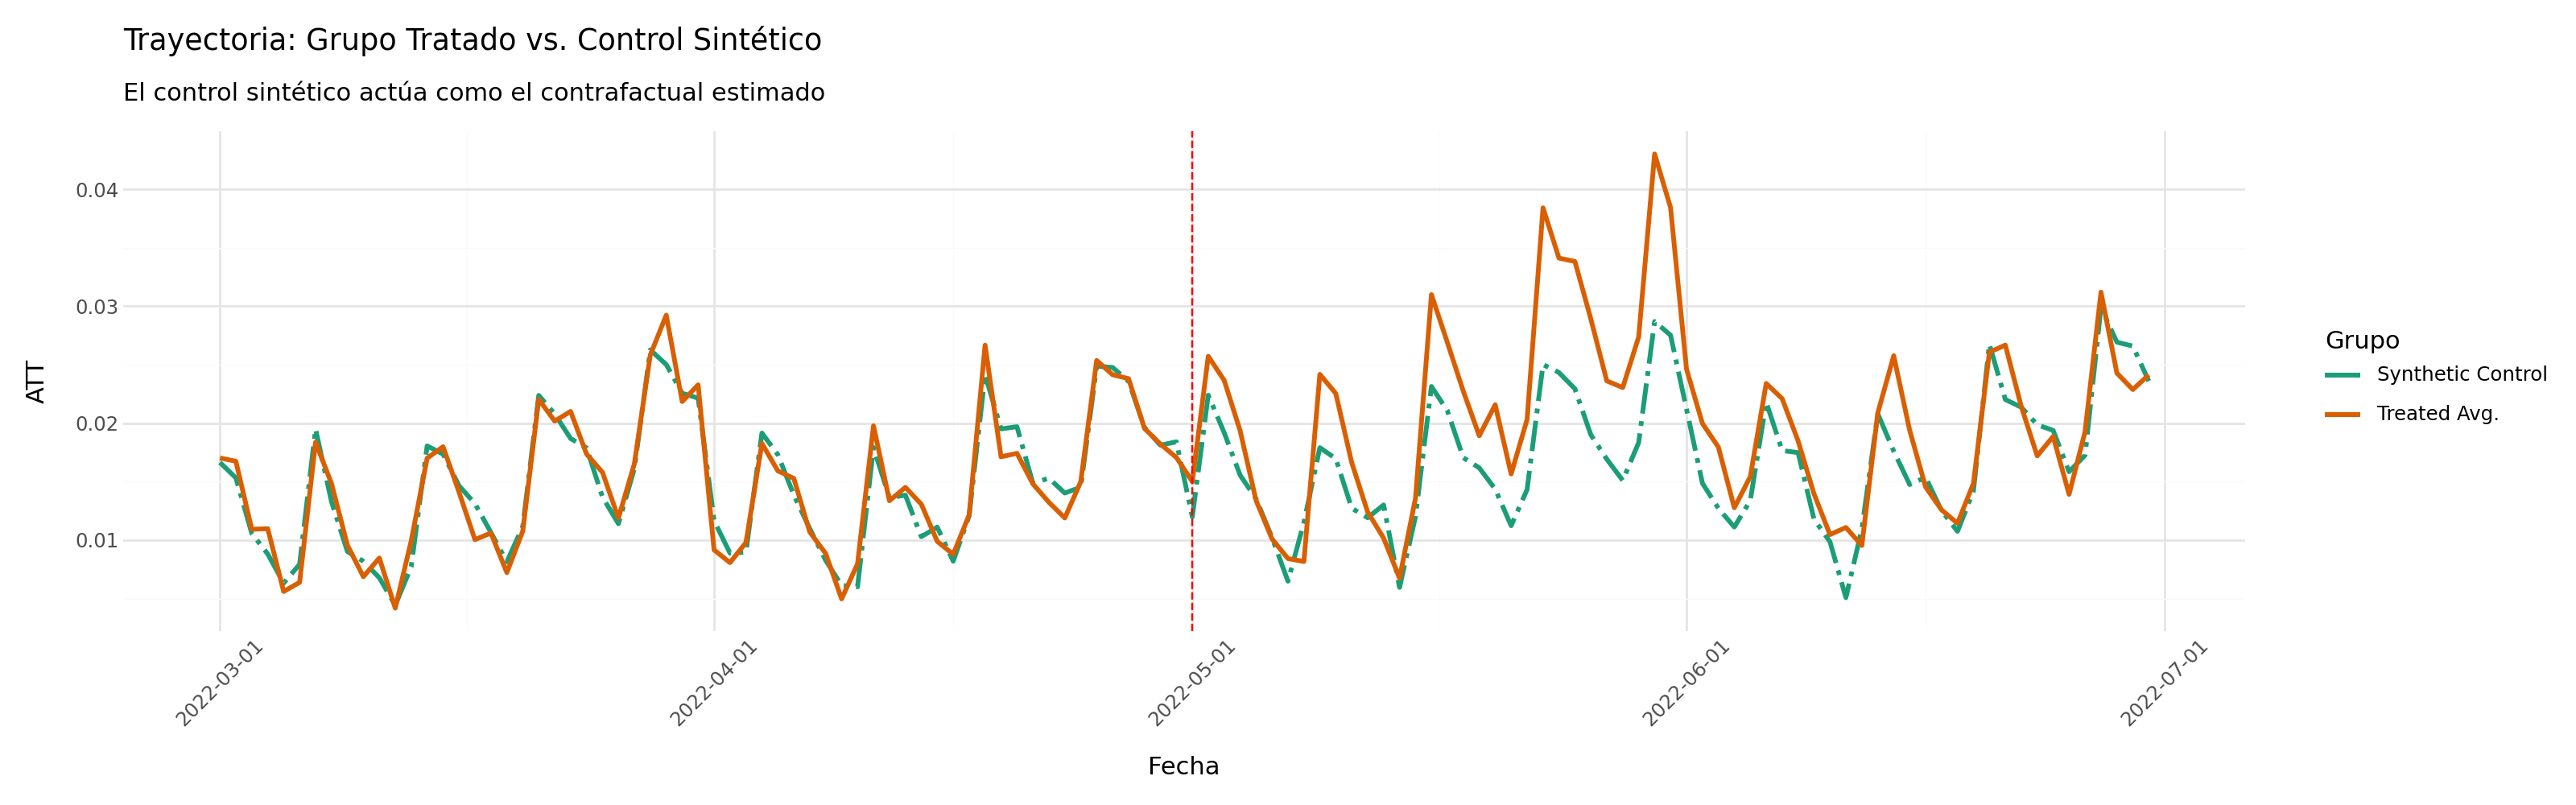

In [114]:
from plotnine import *

(
    ggplot(df_plot, aes(x="date"))
    + geom_line(aes(y="synthetic", color="'Synthetic Control'"), linetype="dashdot", size=1.2)
    + geom_line(aes(y="treated_avg", color="'Treated Avg.'"), size=1.2)
    + geom_vline(xintercept=pd.to_datetime(tr_period), linetype="dashed", color="red")
    + scale_color_manual(
        name="Grupo",
        values={"Synthetic Control": "#1b9e77", "Treated Avg.": "#d95f02"}
    )
    + labs(
        title="Trayectoria: Grupo Tratado vs. Control Sintético",
        subtitle="El control sintético actúa como el contrafactual estimado",
        y="ATT",
        x="Fecha"
    )
    + theme_minimal()
    + theme(
        axis_text_x=element_text(rotation=45),
        figure_size=(16, 5)  # <-- Aquí defines el largo (ancho) y alto del plot
    )
)


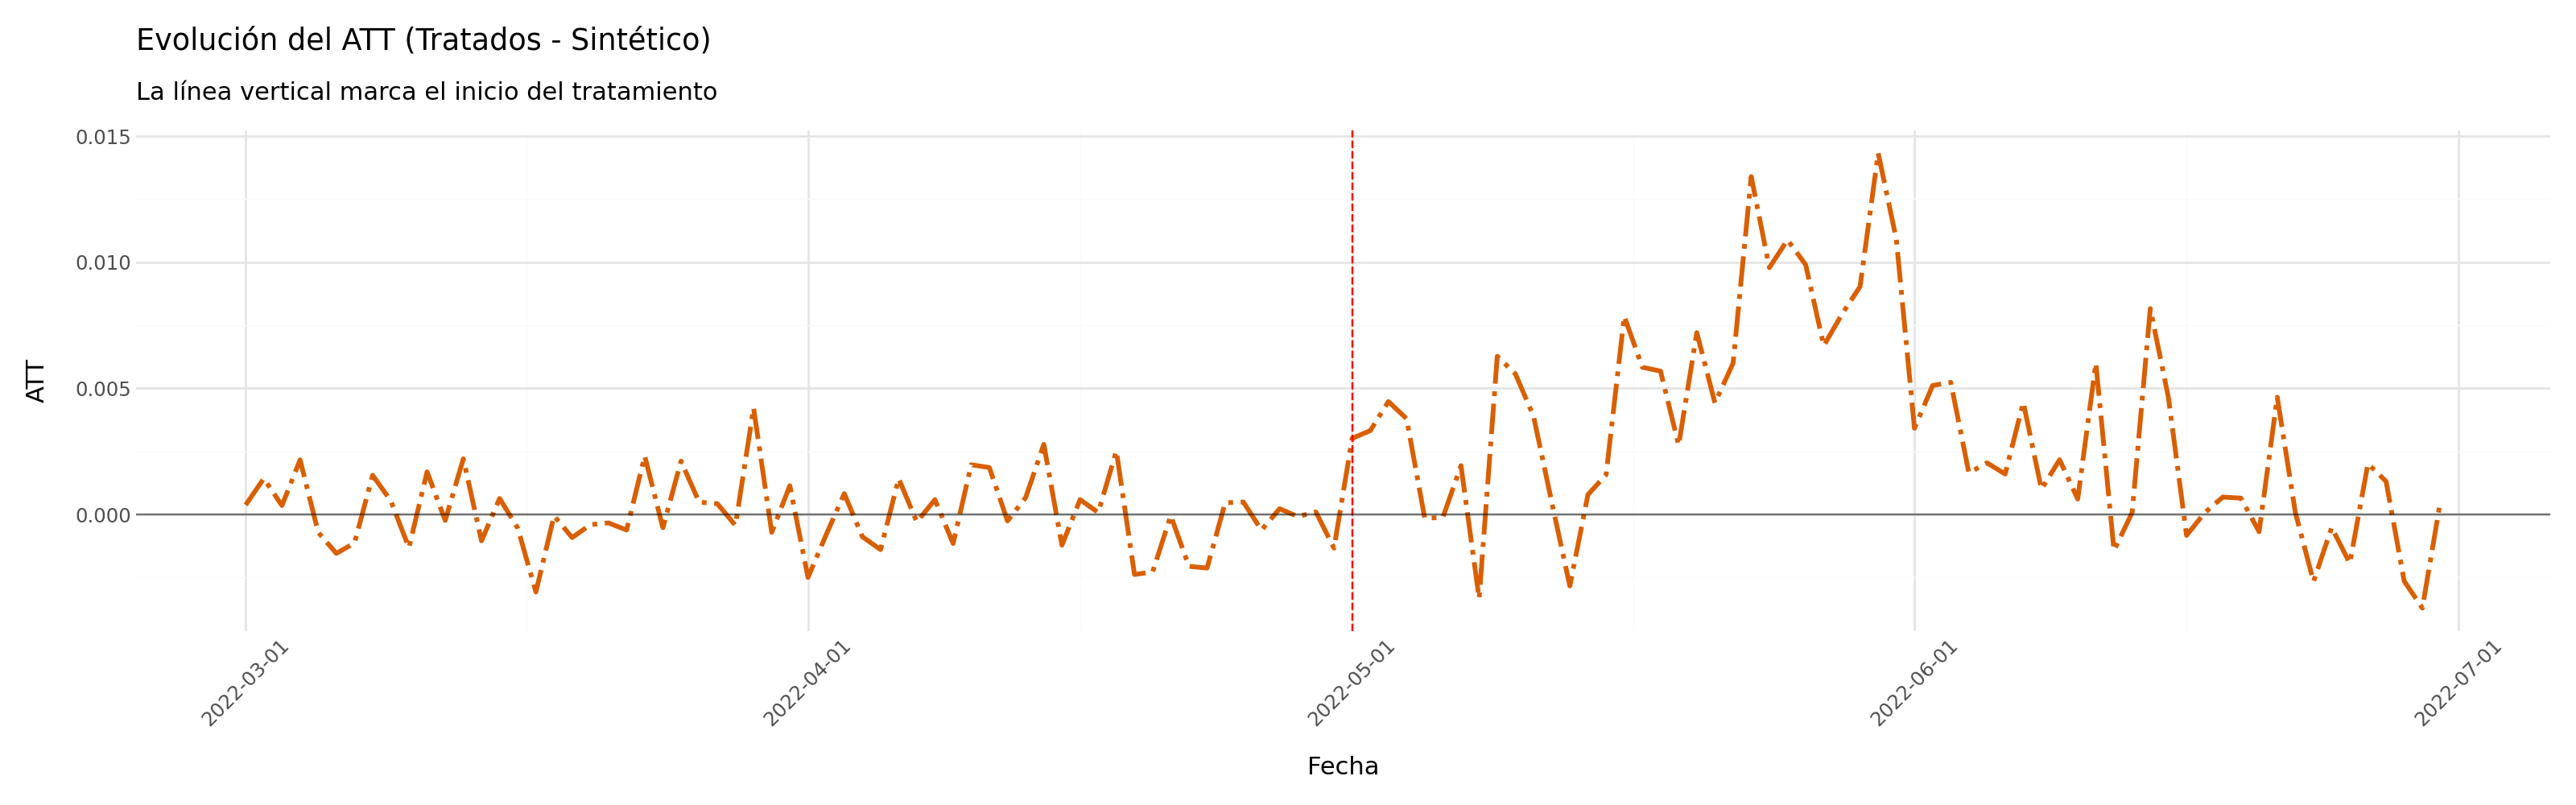

In [115]:
## ATT plotnine

df_plot = df_plot.with_columns(
    ATT = pl.col("treated_avg") - pl.col("synthetic")
)

(
    ggplot(df_plot, aes(x="date", y="ATT"))
    + geom_line(linetype="dashdot", color="#d95f02", size=1.2)
    + geom_vline(xintercept=pd.to_datetime(tr_period), linetype="dashed", color="red", show_legend=True)
    + geom_hline(yintercept=0, linetype="solid", color="black", alpha=0.5)
    + labs(
        title="Evolución del ATT (Tratados - Sintético)",
        subtitle="La línea vertical marca el inicio del tratamiento",
        y="ATT",
        x="Fecha"
    )
    + theme_minimal()
    + theme(
        axis_text_x=element_text(rotation=45),
        figure_size=(16, 5)  # <-- Aquí defines el largo (ancho) y alto del plot
    )
)

## Synthetic Control with Covariants

In [116]:
df_norm_cov = pl.read_csv("../data/online_mkt_cov.csv").with_columns(
    pl.col("date").str.to_date()
)

df_norm_cov.head()

app_download,population,city,state,date,post,treated,app_download_pct,comp_download_pct
f64,i64,str,str,date,i64,i64,f64,f64
3066.0,12396372,"""sao_paulo""","""sao_paulo""",2022-03-01,0,1,0.024733,0.02628
2701.0,12396372,"""sao_paulo""","""sao_paulo""",2022-03-02,0,1,0.021789,0.023925
1927.0,12396372,"""sao_paulo""","""sao_paulo""",2022-03-03,0,1,0.015545,0.01893
1451.0,12396372,"""sao_paulo""","""sao_paulo""",2022-03-04,0,1,0.011705,0.015858
1248.0,12396372,"""sao_paulo""","""sao_paulo""",2022-03-05,0,1,0.010067,0.014548


In [117]:
from toolz import partial

reshaper = partial(reshape_sc_data,
                   df=df_norm_cov,
                   geo_col="city",
                   time_col="date",
                   tr_geos=treated,
                   tr_start_st=str(tr_period))

y_pre_co, y_pre_tr, y_post_co, y_post_tr = reshaper(
    y_col="app_download_pct"
)

x_pre_co, _, x_post_co, _ = reshaper(y_col="comp_download_pct")

In [118]:
def find_w_given_vs(vs, x_co_list, y_tr_pre):
    # Multiplicamos cada DataFrame por su respectivo peso y sumamos columna a columna
    # Primero, eliminamos la columna "date" y convertimos a pandas
    x_weighted = [
        x.drop("date").to_pandas() * v
        for x, v in zip(x_co_list, vs)
    ]
    # Sumamos los DataFrames ponderados
    X_times_v = sum(x_weighted)
    
    model = SyntheticControl()
    model.fit(X_times_v, y_tr_pre)
    return {"loss": model.loss_, "w": model.w_}

# Ejemplo de uso:
find_w_given_vs(
    [1, 0],
    [y_pre_co, x_pre_co],
    y_pre_tr.drop("date").to_pandas().mean(axis=1)
).get("w").round(3)

array([ 0.046,  0.076,  0.089,  0.123, -0.   , -0.   , -0.   , -0.   ,
        0.008, -0.   ,  0.074,  0.037, -0.   ,  0.061, -0.   , -0.   ,
        0.083, -0.   ,  0.   ,  0.067, -0.   ,  0.   ,  0.   ,  0.   ,
       -0.   ,  0.086,  0.092,  0.088, -0.   , -0.   , -0.   , -0.   ,
        0.   , -0.   , -0.   , -0.   , -0.   , -0.   , -0.   , -0.   ,
       -0.   ,  0.   ,  0.061, -0.   ,  0.01 , -0.   , -0.   ])

In [119]:
from scipy.optimize import minimize

def v_loss(vs):
    return find_w_given_vs(vs,[y_pre_co, x_pre_co],
                            y_pre_tr.drop("date").to_pandas().mean(axis=1)).get("loss")

v_solution = minimize(v_loss, [0, 0], method='L-BFGS-B')
v_solution.x


array([1.80162849, 0.00311641])

In [120]:
w_cov = find_w_given_vs(v_solution.x,
    [y_pre_co, x_pre_co],
    y_pre_tr.drop("date").to_pandas().mean(axis=1)).get("w").round(3)
w_cov

array([ 0.   ,  0.086,  0.147,  0.051, -0.   , -0.   ,  0.   ,  0.007,
        0.031, -0.   ,  0.01 ,  0.   ,  0.16 ,  0.009,  0.   , -0.   ,
        0.034,  0.   ,  0.   ,  0.023, -0.   , -0.   ,  0.   ,  0.   ,
       -0.   ,  0.169,  0.048,  0.036,  0.035,  0.   ,  0.   , -0.   ,
        0.   , -0.   ,  0.053,  0.   ,  0.084, -0.   ,  0.   , -0.   ,
       -0.   ,  0.   ,  0.016, -0.   , -0.   , -0.   , -0.   ])

In [121]:
# Paso 1: Convertimos los DataFrames a numpy, quitando la columna "date"
y_post_co_np = y_post_co.drop("date").to_numpy()
x_post_co_np = x_post_co.drop("date").to_numpy()

# Paso 2: Multiplicamos cada matriz por su respectivo v
X_times_v = y_post_co_np * v_solution.x[0] + x_post_co_np * v_solution.x[1]

# Paso 3: Producto matricial con los pesos w_cov
y0_hat = X_times_v @ w_cov

att = y_post_tr.drop("date").to_pandas().mean(axis=1) - y0_hat
att

0     2.83e-03
1     3.95e-03
2     4.96e-03
3     4.27e-03
4     7.94e-04
        ...   
56    2.24e-03
57    1.92e-03
58   -2.60e-03
59   -2.98e-03
60    1.70e-04
Length: 61, dtype: float64

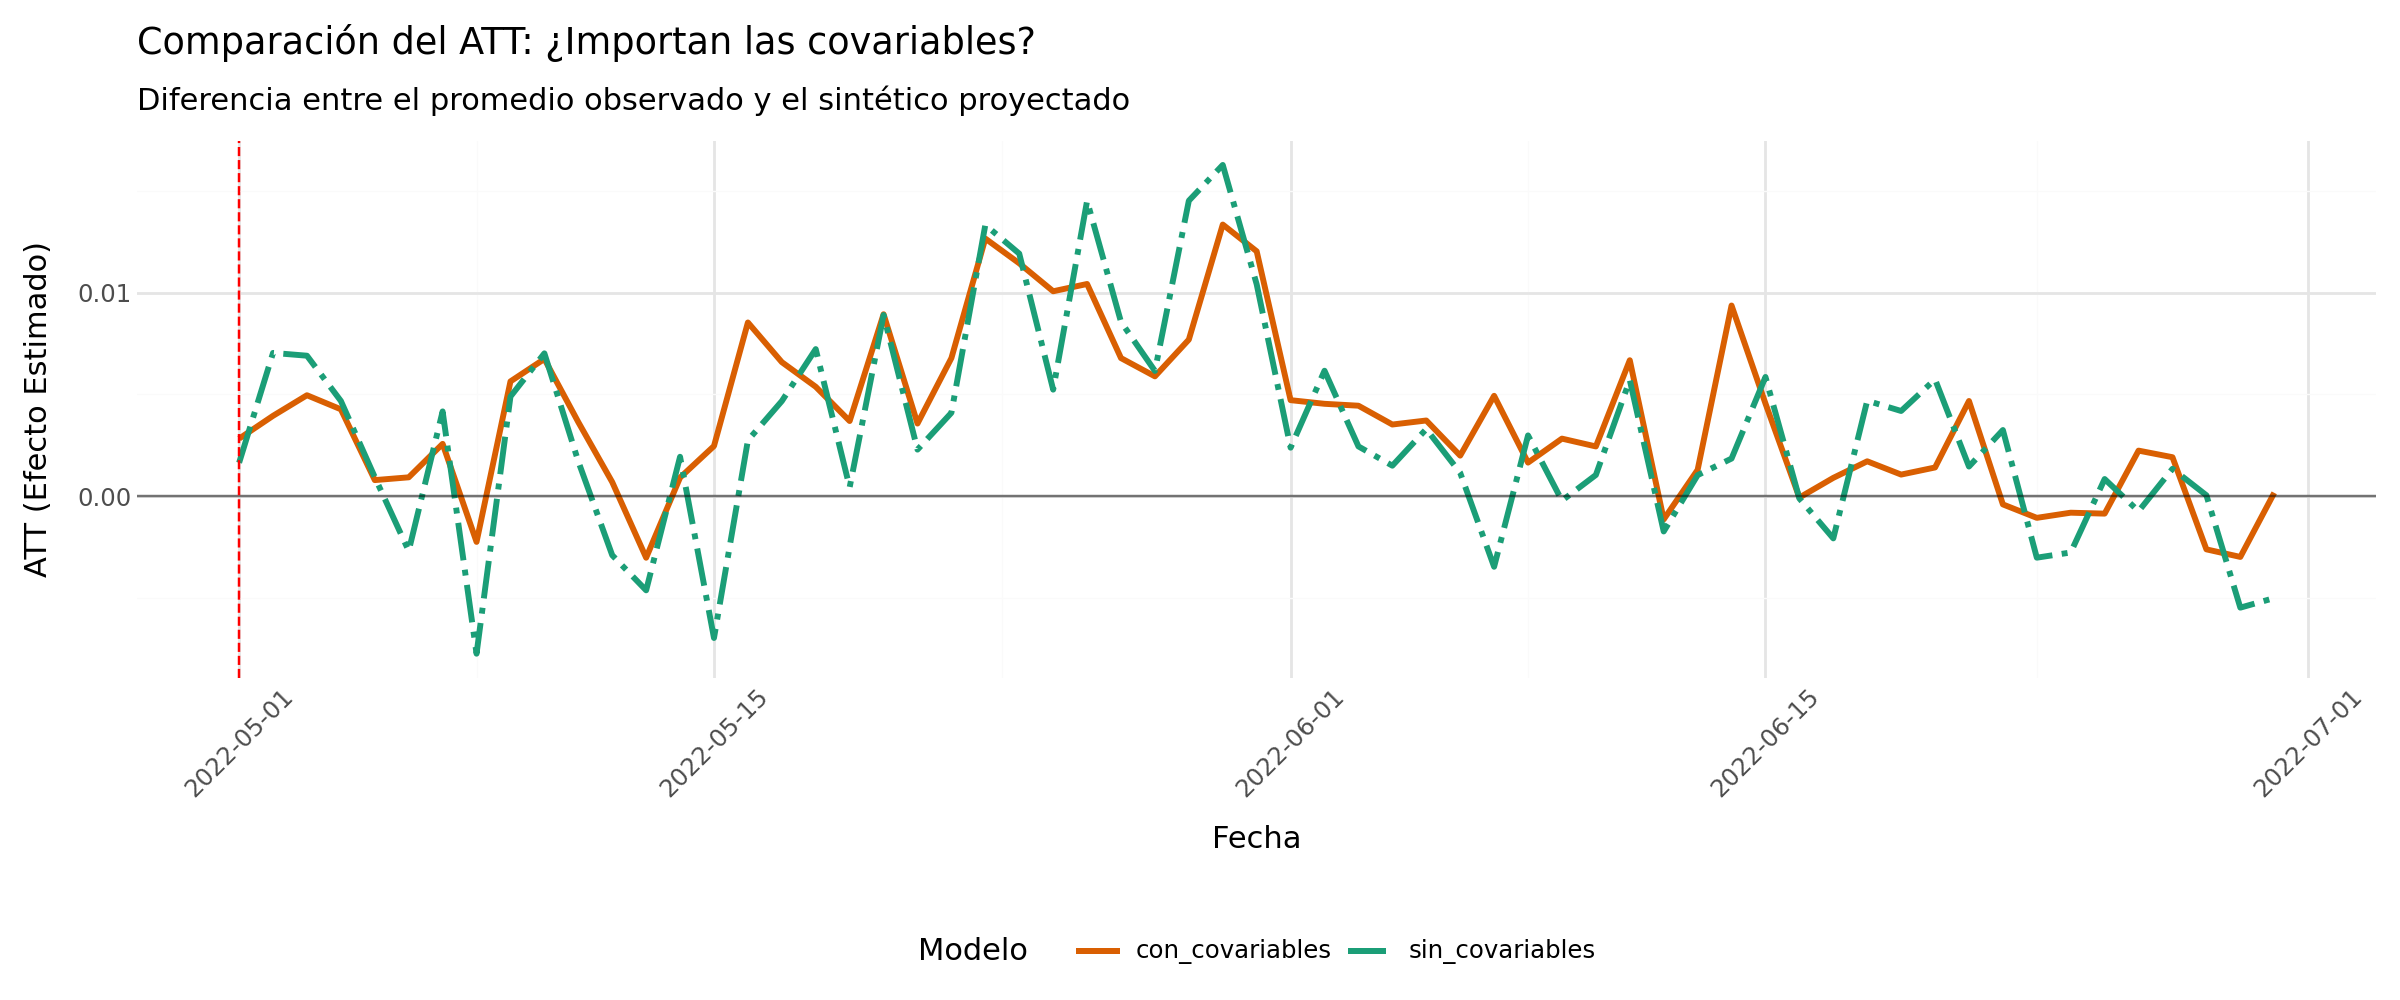

In [122]:
# 1. Preparar los datos del ATT para ambos modelos
# Extraemos el promedio real de los tratados en el periodo post
treated_avg_post = y_post_tr.drop("date").to_pandas().mean(axis=1).values

# Creamos un DataFrame consolidado con Polars
df_att_compare = (
    y_post_tr.select("date")
    .with_columns(
        sin_covariables = treated_avg_post - y0_tr_hat.values,
        con_covariables = treated_avg_post - y0_hat
    )
    # Transformamos a formato largo (tidy) para plotnine
    .unpivot(
        index="date", 
        variable_name="Modelo", 
        value_name="ATT"
    )
)

# 2. Visualización con Plotnine
(
    ggplot(df_att_compare, aes(x="date", y="ATT", color="Modelo", linetype="Modelo"))
    + geom_line(size=1.2)
    + geom_hline(yintercept=0, color="black", alpha=0.5)
    + geom_vline(xintercept=pd.to_datetime(tr_period), linetype="dashed", color="red")
    + scale_color_manual(values={"sin_covariables": "#1b9e77", "con_covariables": "#d95f02"})
    + scale_linetype_manual(values={"sin_covariables": "dashdot", "con_covariables": "solid"})
    + labs(
        title="Comparación del ATT: ¿Importan las covariables?",
        subtitle="Diferencia entre el promedio observado y el sintético proyectado",
        x="Fecha",
        y="ATT (Efecto Estimado)"
    )
    + theme_minimal()
    + theme(
        axis_text_x=element_text(rotation=45),
        figure_size=(12, 5),
        legend_position="bottom"
    )
)

## Debiasing Synthetic Control

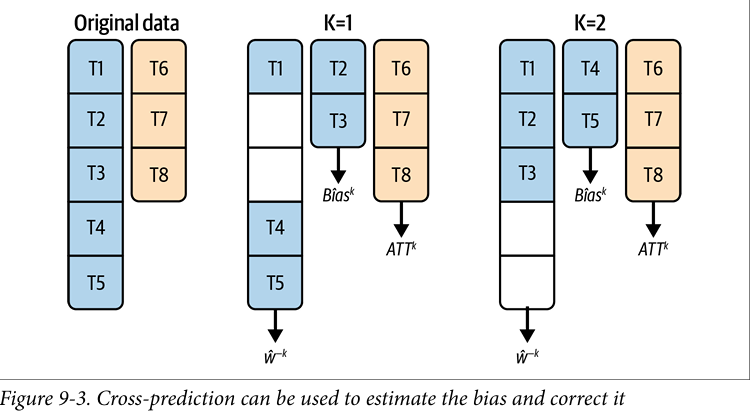

In [123]:
import numpy as np
import polars as pl

def debiased_sc_atts(
    y_pre_co: pl.DataFrame,
    y_pre_tr: pl.DataFrame | pl.Series,
    y_post_co: pl.DataFrame,
    y_post_tr: pl.DataFrame | pl.Series,
    K: int = 3,
    time_col: str = "date",
) -> pl.DataFrame:
    def _to_target_series(df_or_s: pl.DataFrame | pl.Series) -> tuple[pl.Series, pl.Series | None]:
        if isinstance(df_or_s, pl.Series):
            return df_or_s, None

        cols = df_or_s.columns
        t_col = time_col if time_col in cols else None
        y_cols = [c for c in cols if c != t_col]

        if len(y_cols) == 0:
            raise ValueError("No hay columnas de resultado en y_pre_tr/y_post_tr.")

        y_s = (
            df_or_s.select(pl.mean_horizontal(y_cols).alias("y_tr"))
            .to_series()
        )

        t_s = df_or_s.get_column(t_col) if t_col is not None else None
        return y_s, t_s

    def _drop_time(df: pl.DataFrame) -> pl.DataFrame:
        return df.drop(time_col) if time_col in df.columns else df

    y_pre_tr_s, _ = _to_target_series(y_pre_tr)
    y_post_tr_s, post_time = _to_target_series(y_post_tr)

    x_pre = _drop_time(y_pre_co)
    x_post = _drop_time(y_post_co)

    n_pre = y_pre_tr_s.len()
    n_post = y_post_tr_s.len()

    if K < 1:
        raise ValueError("K debe ser >= 1.")

    block_size = int(min(np.floor(n_pre / K), n_post))
    if block_size < 1:
        raise ValueError("No hay suficientes observaciones para construir folds.")

    holdout_idx_all = np.arange(n_pre - K * block_size, n_pre)
    blocks = np.array_split(holdout_idx_all, K)

    x_pre_np = x_pre.to_numpy()
    y_pre_np = y_pre_tr_s.to_numpy()
    x_post_np = x_post.to_numpy()
    y_post_np = y_post_tr_s.to_numpy()

    fold_atts: list[np.ndarray] = []

    for hold_out in blocks:
        train_mask = np.ones(n_pre, dtype=bool)
        train_mask[hold_out] = False

        model = SyntheticControl()
        model.fit(
            x_pre_np[train_mask],
            y_pre_np[train_mask],
        )

        bias_hat = np.mean(
            y_pre_np[hold_out] - model.predict(x_pre_np[hold_out])
        )

        y0_hat_post = model.predict(x_post_np)
        fold_atts.append((y_post_np - y0_hat_post) - bias_hat)

    result = pl.DataFrame({
        f"att_fold_{k + 1}": fold_atts[k] for k in range(K)
    }).with_columns(
        pl.mean_horizontal(pl.all()).alias("att_debiased")
    )

    if post_time is not None:
        result = result.with_columns(post_time.alias(time_col)).select(time_col, pl.exclude(time_col))

    return result

In [124]:
# ATT debiased por fold + promedio debiased
df_att_debiased = debiased_sc_atts(
    y_pre_co=y_pre_co,
    y_pre_tr=y_pre_tr,
    y_post_co=y_post_co,
    y_post_tr=y_post_tr,
    K=3,
    time_col="date",
)

df_att_debiased.head()

date,att_fold_1,att_fold_2,att_fold_3,att_debiased
date,f64,f64,f64,f64
2022-05-01,0.003314,0.002475,0.003162,0.002984
2022-05-02,0.003544,0.002844,0.003368,0.003252
2022-05-03,0.004644,0.003698,0.004759,0.004367
2022-05-04,0.004706,0.002866,0.003603,0.003725
2022-05-05,0.000134,-0.000541,0.000173,-0.000078


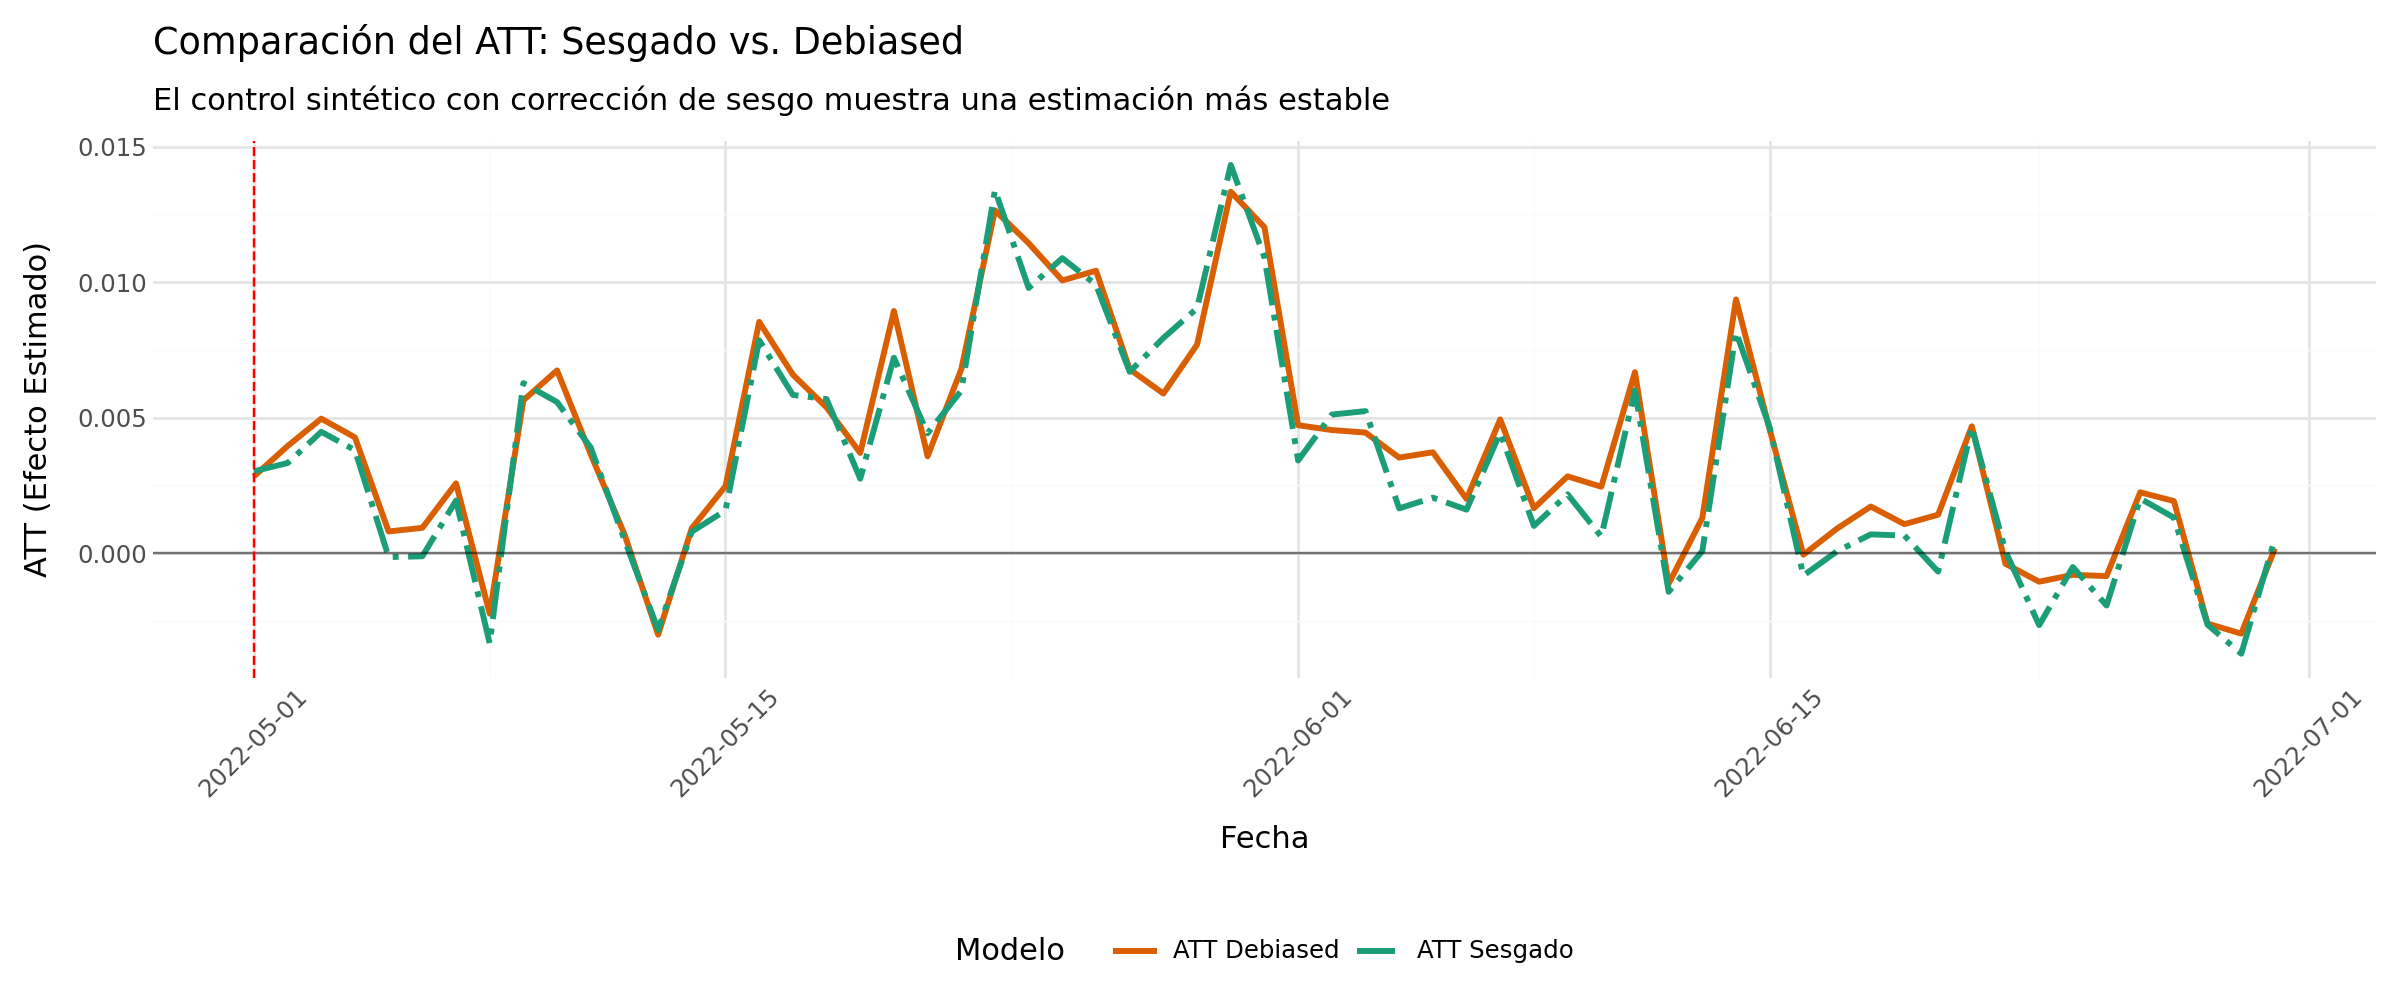

In [125]:
model_biased = SyntheticControl()
model_biased.fit(y_pre_co.drop("date").to_pandas(), y_pre_tr.drop("date").to_pandas().mean(axis=1))

att_biased = y_post_tr.drop("date").to_pandas().mean(axis=1) - model_biased.predict(y_post_co.drop("date").to_pandas())

# Plot comparativo entre ATT sesgado y debiased
df_att_compare = pl.DataFrame({
    "date": df_att_debiased["date"],
    "ATT Sesgado": att_biased,
    "ATT Debiased": att
}).unpivot(
    index="date",
    variable_name="Modelo",
    value_name="ATT"
)

(
    ggplot(df_att_compare, aes(x="date", y="ATT", color="Modelo", linetype="Modelo"))
    + geom_line(size=1.2)
    + geom_hline(yintercept=0, color="black", alpha=0.5)
    + geom_vline(xintercept=pd.to_datetime(tr_period), linetype="dashed", color="red")
    + scale_color_manual(values={"ATT Sesgado": "#1b9e77", "ATT Debiased": "#d95f02"})
    + scale_linetype_manual(values={"ATT Sesgado": "dashdot", "ATT Debiased": "solid"})
    + labs(
        title="Comparación del ATT: Sesgado vs. Debiased",
        subtitle="El control sintético con corrección de sesgo muestra una estimación más estable",
        x="Fecha",
        y="ATT (Efecto Estimado)"
    )
    + theme_minimal()
    + theme(
        axis_text_x=element_text(rotation=45),
        figure_size=(12, 5),
        legend_position="bottom"
    )
)

## Inference

In [126]:
df_att_debiased.head()

date,att_fold_1,att_fold_2,att_fold_3,att_debiased
date,f64,f64,f64,f64
2022-05-01,0.003314,0.002475,0.003162,0.002984
2022-05-02,0.003544,0.002844,0.003368,0.003252
2022-05-03,0.004644,0.003698,0.004759,0.004367
2022-05-04,0.004706,0.002866,0.003603,0.003725
2022-05-05,0.000134,-0.000541,0.000173,-0.000078


In [127]:
att_fold_cols = [c for c in df_att_debiased.columns if c.startswith("att_fold_")]

atts_k = (

    df_att_debiased

    .select([pl.col(c).mean().alias(c) for c in att_fold_cols])

    .to_numpy()

    .flatten()

)

atts_k

array([0.00414872, 0.00260513, 0.00317687])

In [128]:
att = float(np.mean(atts_k))



att

0.003310235951728954

Para la inferencia, la idea es estimar un **error estándar** a partir de los $K$ ATT por fold. Intuitivamente, cada fold te da un “mini‑experimento” y la dispersión entre esos ATT refleja la incertidumbre.

Formalmente:

$$
\sigma = \left(1 + \frac{T_{\text{post}}}{\text{BlockSize}}\right) \cdot 
\sqrt{\frac{1}{K-1}\sum_{k=1}^{K}\left(ATT_k - \overline{ATT}\right)^2}
$$

y el error estándar:

$$
SE = \frac{\sigma}{\sqrt{K}}
$$

**Nota clave:** al computar la desviación estándar muestral en Python, debes usar `ddof=1` para que sea insesgada.

In [129]:
K = len(atts_k)

T0 = len(y_pre_co)

T1 = len(y_post_co)

block_size = min(np.floor(T0 / K), T1)



se_hat = (

    np.sqrt(1 + ((K * block_size) / T1))

    * atts_k.std(ddof=1)

    / np.sqrt(K)

)



print("SE:", se_hat)

SE: 0.0006345693279981826


In [130]:
from scipy.stats import t

# Calculamos el intervalo de confianza para el ATT usando la t de Student

# att, se_hat y K ya están definidos en celdas anteriores



alpha = 0.1  # Nivel de significancia (90% intervalo de confianza)

if K <= 1:

    raise ValueError("Se necesitan al menos 2 folds para inferencia t (K > 1).")



t_crit = t.ppf(1 - alpha / 2, K - 1)

ic_att = [

    att - t_crit * se_hat,

    att + t_crit * se_hat,

]

float(ic_att[0]), float(ic_att[1])

(0.0014573026642395077, 0.0051631692392184)

## Synthetic Difference-in-Differences

#### DiD Refresher

In [131]:
# Entrenamos el modelo con los datos pre-tratamiento
sc_model = SyntheticControl()
sc_model.fit(
	y_pre_co.drop("date").to_pandas(), 
	y_pre_tr.drop("date").to_pandas().mean(axis=1)
)

# Calculamos el promedio real de los tratados post-tratamiento
treated_avg_post = y_post_tr.drop("date").to_pandas().mean(axis=1)

# Predecimos el contrafactual sintético para el periodo post-tratamiento
y0_hat_post = sc_model.predict(y_post_co.drop("date").to_pandas())

# Calculamos el ATT promedio post-tratamiento
att_post = (treated_avg_post - y0_hat_post).mean()
float(att_post)

0.0033270409793961417

In [134]:
# Para Pandas (que es lo que parece que estás visualizando)

import pandas as pd

pd.set_option('display.float_format', '{:.2e}'.format)



# Para Polars

# pl.Config.set_tbl_rows(10)



unit_w = pl.DataFrame({

    "city": y_pre_co.drop("date").columns,

    "unit_weight": sc_model.w_

}).sort('city')



unit_w.to_pandas().head()

,city,unit_weight
0,ananindeua,-8.38e-06
1,aparecida_de_goiania,-1.30e-06
2,aracaju,-7.78e-06
3,belem,-1.20e-05
4,belford_roxo,-5.58e-06


In [139]:
# Primero, calculamos la media de la columna 'treated' para usar en el fill_null
mean_treated = df_norm.select(pl.col("treated").mean()).item()

# Creamos el DataFrame combinado
df_with_w = (
    df_norm
    .with_columns(
        tr_post = pl.col("post") * pl.col("treated")
    )
    .join(unit_w, on="city", how="left")
    .with_columns(
        unit_weight = pl.col("unit_weight").fill_null(mean_treated)
    )
)

df_with_w.sample(5)

app_download,population,city,state,date,post,treated,app_download_pct,tr_post,unit_weight
f64,i64,str,str,date,i64,i64,f64,i64,f64
120.0,896708,"""natal""","""rio_grande_do_norte""",2022-04-25,0,0,0.013382,0,-0.00002
477.0,6775561,"""rio_de_janeiro""","""rio_de_janeiro""",2022-04-02,0,0,0.00704,0,0.045654
46.0,1963726,"""curitiba""","""parana""",2022-05-21,1,0,0.002342,0,-0.000011
134.0,481725,"""maua""","""sao_paulo""",2022-06-02,1,0,0.027817,0,-0.000007
546.0,2900319,"""salvador""","""bahia""",2022-05-30,1,0,0.018826,0,0.088537


In [142]:
import statsmodels.formula.api as smf  # Importamos statsmodels para regresión con fórmulas

# Filtramos datos para excluir unidades con peso casi cero (no relevantes para el control sintético)
filtered_data = df_with_w.filter(pl.col("unit_weight") >= 1e-10)

# Ajustamos el modelo WLS: Y ~ tratamiento_post + dummies_por_fecha, con pesos del control sintético
mod = smf.wls(
    "app_download_pct ~ tr_post + C(date)",  # Fórmula: resultado ~ interacción_tratamiento + controles_temporales
    data=filtered_data.to_pandas(),  # Convertimos a pandas porque statsmodels lo requiere
    weights=filtered_data.select(pl.col("unit_weight")).to_pandas().values.flatten()  # Pesos para WLS
)

# Ajustamos el modelo y extraemos el coeficiente del ATT (tr_post)
att_estimate = mod.fit().params["tr_post"]
float(att_estimate)

0.0033293800074678612

### Estimating Time Weights

In [143]:
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.utils.validation import check_X_y, check_array, check_is_fitted
import cvxpy as cp

class SyntheticControl(BaseEstimator, RegressorMixin):

    def __init__(self, fit_intercept=False):
        self.fit_intercept = fit_intercept

    def fit(self, y_pre_co, y_pre_tr):

        y_pre_co, y_pre_tr = check_X_y(y_pre_co, y_pre_tr)
        
        # add intercept
        intercept = np.ones((y_pre_co.shape[0], 1))*self.fit_intercept
        X = np.concatenate([intercept, y_pre_co], axis=1)
        w = cp.Variable(X.shape[1])
        
        objective = cp.Minimize(cp.sum_squares(X@w - y_pre_tr))
        constraints = [cp.sum(w[1:]) == 1, w[1:] >= 0]
        
        problem = cp.Problem(objective, constraints)
        
        self.loss_ = problem.solve(verbose=False)
        self.w_ = w.value[1:] # remove intercept
        
        self.is_fitted_ = True
        return self
        
        
    def predict(self, y_co):

        check_is_fitted(self)
        y_co = check_array(y_co)
        
        return y_co @ self.w_

In [144]:
time_sc = SyntheticControl(fit_intercept=True)

time_sc.fit(
    y_pre_co.drop("date").to_pandas().T,  # Transponemos y convertimos a pandas para sklearn
    y_post_co.drop("date").to_pandas().mean(axis=0)  # Promedio por ciudad en post-periodo
)

# Creamos el DataFrame con pesos temporales usando Polars
time_w = pl.DataFrame({
    "date": y_pre_co["date"],
    "time_weight": time_sc.w_
})

time_w.tail()  # Mostramos las últimas filas para verificar

date,time_weight
date,f64
2022-04-26,-0.000011
2022-04-27,0.071965
2022-04-28,-0.000002
2022-04-29,0.07835
2022-04-30,0.000002


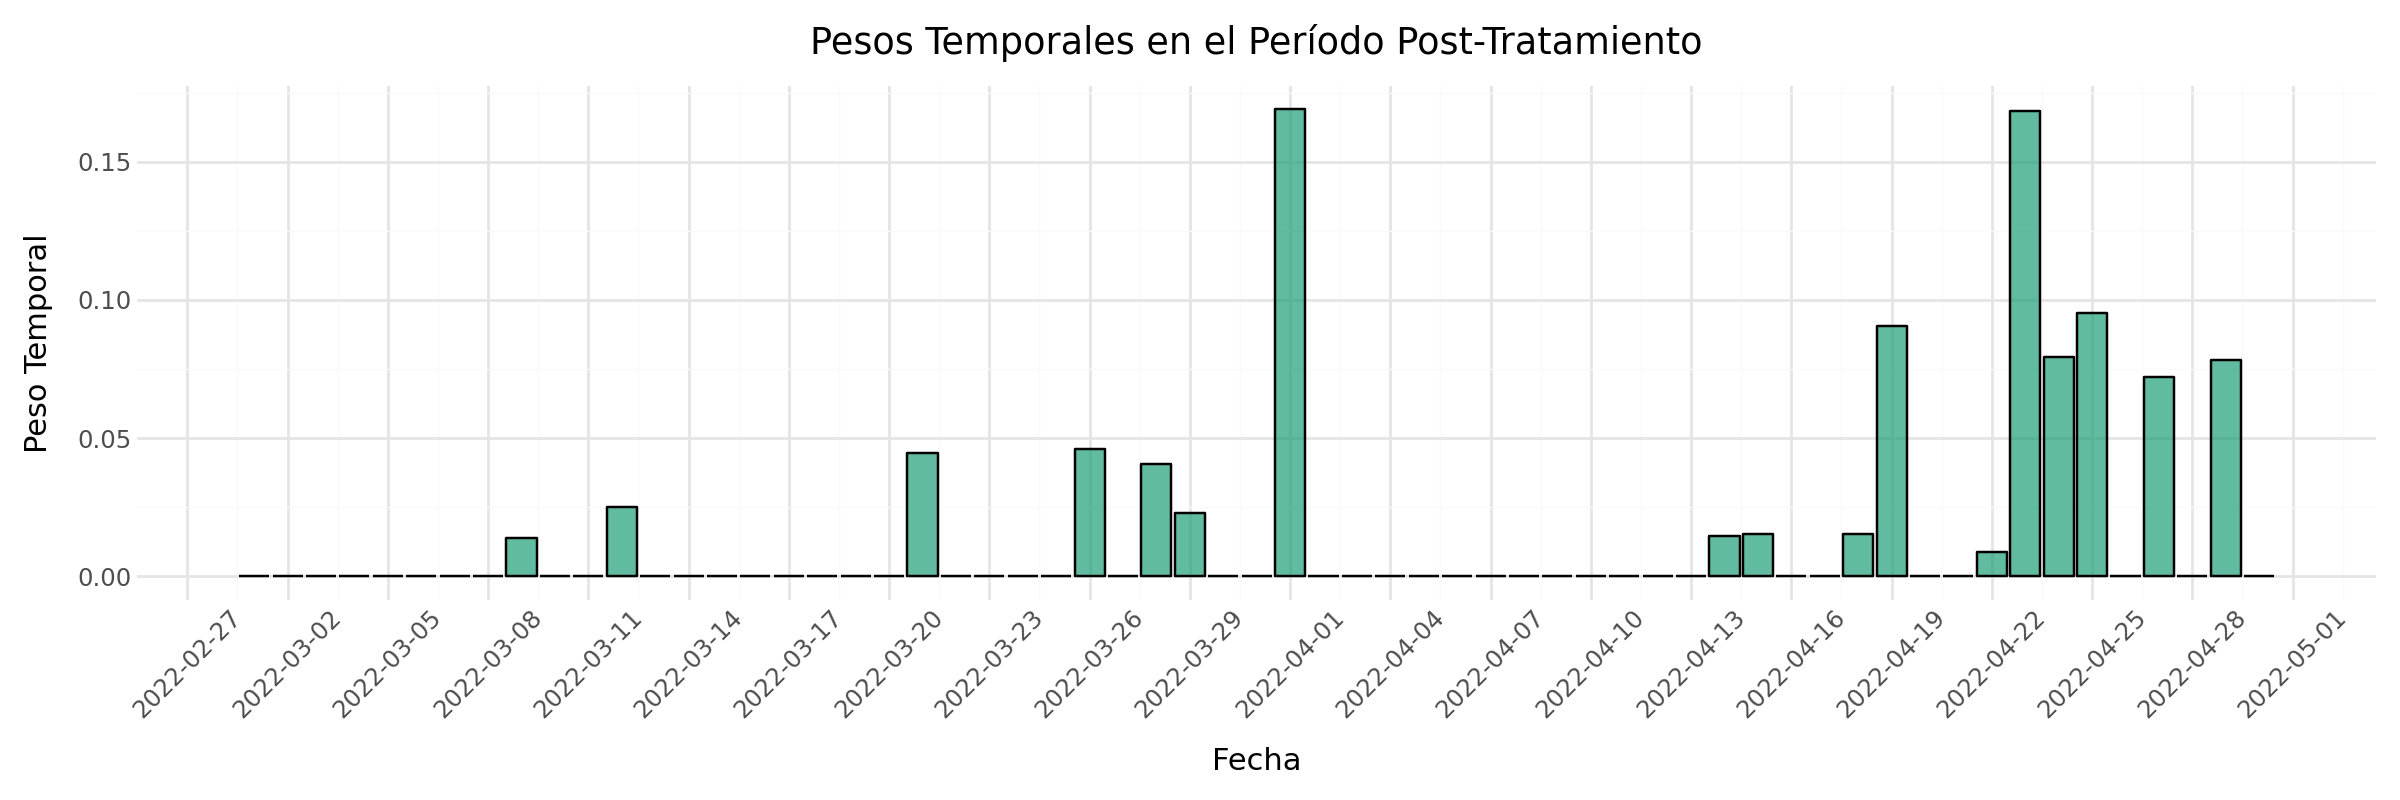

In [150]:

(
    ggplot(time_w, aes(x="date", y="time_weight"))
    + geom_col(fill="#1b9e77", color="black", alpha=0.7)
    + scale_x_date(date_breaks="3 day")
    + labs(
        title="Pesos Temporales en el Período Post-Tratamiento",
        x="Fecha",
        y="Peso Temporal"
    )
    + theme_minimal()
    + theme(axis_text_x=element_text(rotation=45), figure_size=(12, 4))
)


In [158]:
scdid_df = (
    df_with_w
    .join(time_w, on="date", how="left")
    .with_columns(
        time_weight=pl.col("time_weight").fill_null(df_norm.select("post").mean().item())
    )
    .with_columns(
        weight=pl.col("time_weight")*pl.col("unit_weight")
    )
)
scdid_df.head()

app_download,population,city,state,date,post,treated,app_download_pct,tr_post,unit_weight,time_weight,weight
f64,i64,str,str,date,i64,i64,f64,i64,f64,f64,f64
3066.0,12396372,"""sao_paulo""","""sao_paulo""",2022-03-01,0,1,0.024733,0,0.06,-0.000006,-3.5618e-7
2701.0,12396372,"""sao_paulo""","""sao_paulo""",2022-03-02,0,1,0.021789,0,0.06,0.000011,6.4209e-7
1927.0,12396372,"""sao_paulo""","""sao_paulo""",2022-03-03,0,1,0.015545,0,0.06,-0.000004,-2.4134e-7
1451.0,12396372,"""sao_paulo""","""sao_paulo""",2022-03-04,0,1,0.011705,0,0.06,0.000002,9.3784e-8
1248.0,12396372,"""sao_paulo""","""sao_paulo""",2022-03-05,0,1,0.010067,0,0.06,0.000004,2.4505e-7


In [162]:
did_model = smf.wls(
    "app_download_pct ~ treated*post",
    data=scdid_df.filter(pl.col("weight")>1e-10).to_pandas(),
    weights=scdid_df.filter(pl.col("weight")>1e-10).select(pl.col("weight"))
).fit()

float(did_model.params["treated:post"])

0.004086196405593091

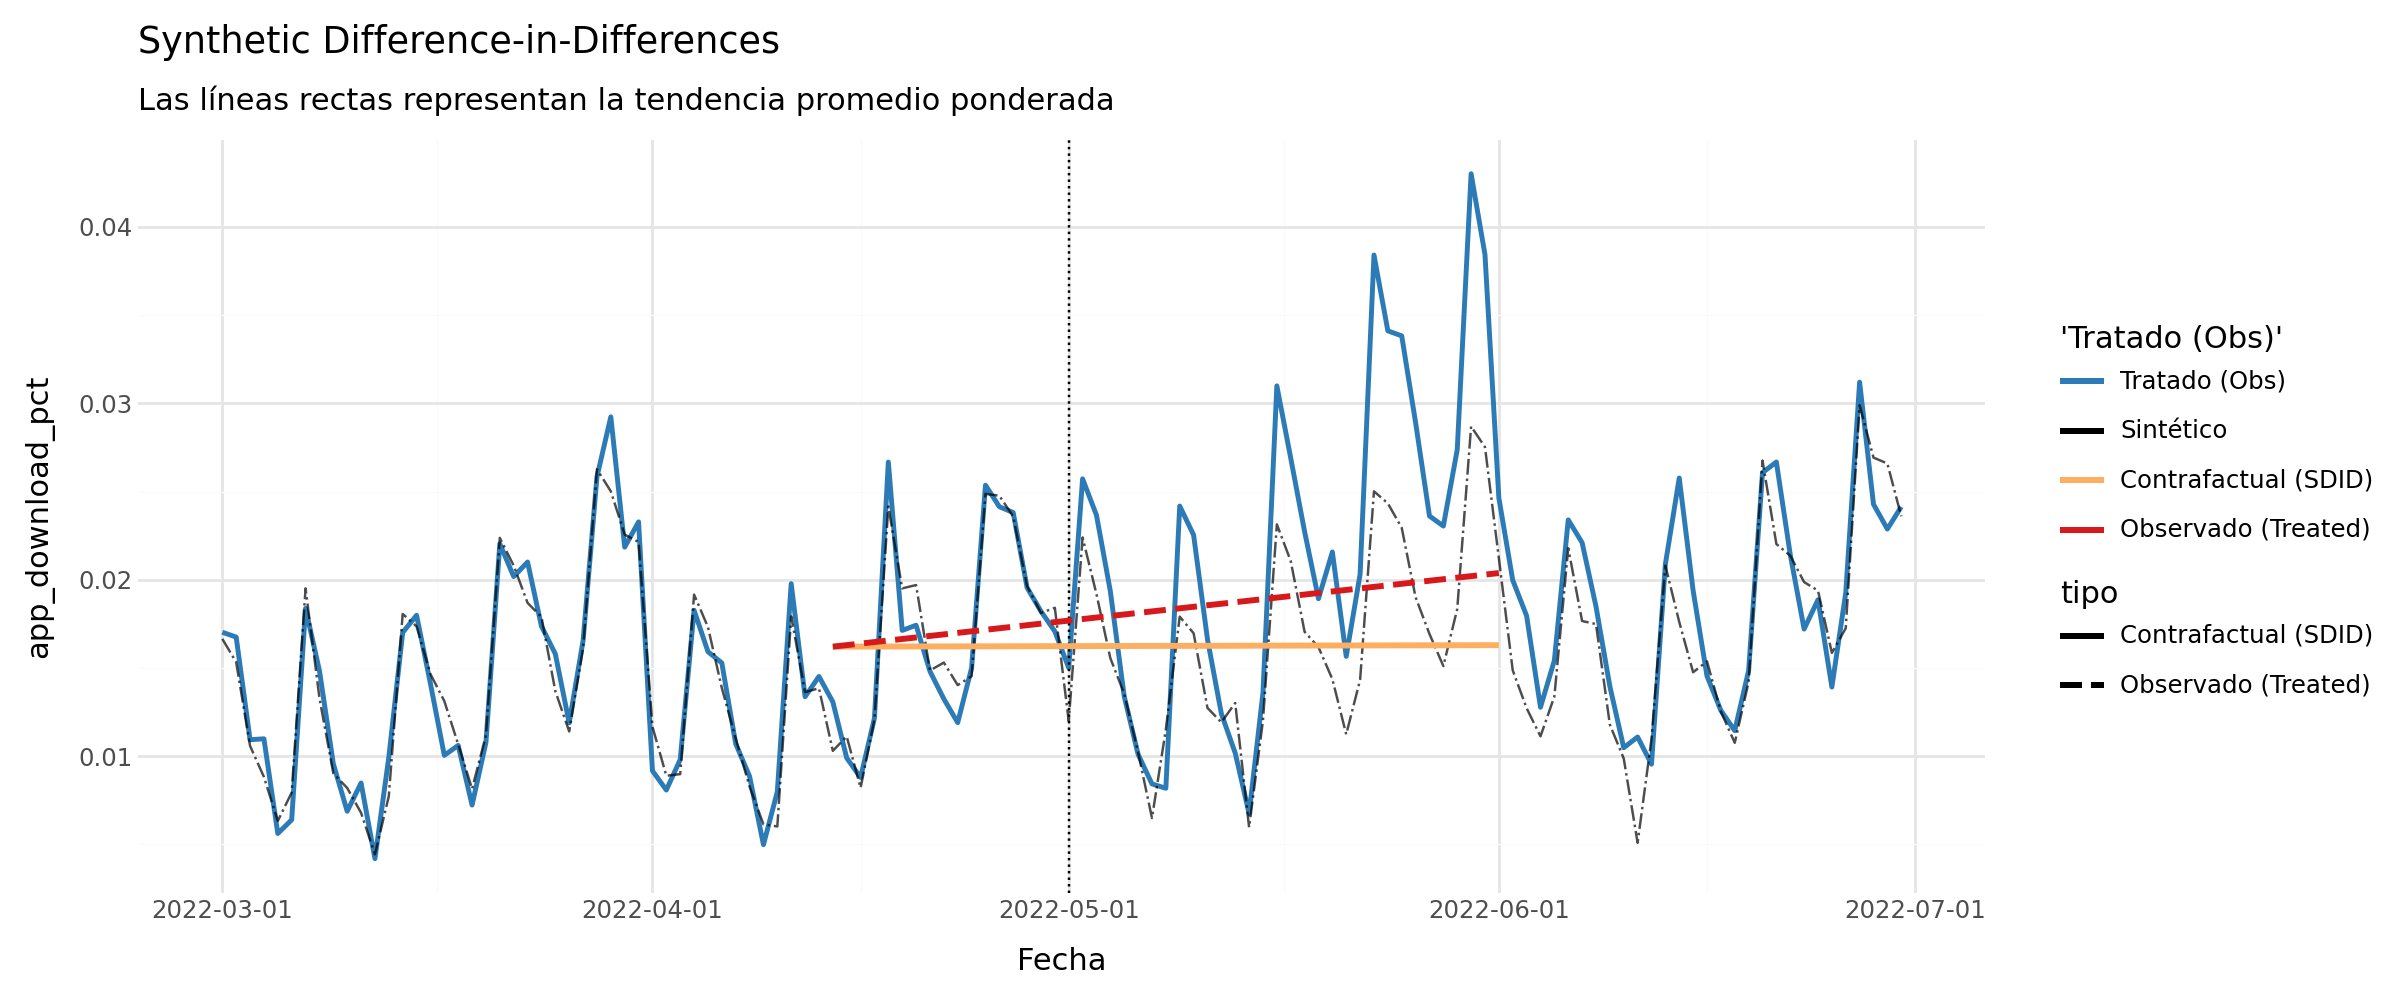

In [167]:
import pandas as pd
import numpy as np
from plotnine import *

# 1. Cálculo de puntos de anclaje (Weighted Averages)
# Calculamos el índice ponderado para el periodo pre-tratamiento
time_weights_np = time_w["time_weight"].to_numpy()
indices = np.arange(len(time_weights_np))
weighted_idx = int(round((time_weights_np * indices).sum()))
avg_pre_period = time_w["date"][weighted_idx]

# Punto fijo para el post-periodo (puedes ajustar esta fecha)
avg_post_period = pd.to_datetime("2022-06-01")

# 2. Extracción de coeficientes del modelo DiD
params = did_model.params
beta0 = params["Intercept"]
beta1 = params["treated"]
beta2 = params["post"]
delta = params["treated:post"]

# Coordenadas SDID
# A: Pre-Tratado, B: Post-Tratado, C: Post-Contrafactual
pre_treat = beta0 + beta1
post_treat = beta0 + beta1 + beta2 + delta
sc_did_y0 = beta0 + beta1 + beta2 # El contrafactual si siguiera la tendencia sintética

# 3. Preparación de datos para líneas de tendencia (Segments)
df_segments = pd.DataFrame({
    'x': [avg_pre_period, avg_pre_period],
    'xend': [avg_post_period, avg_post_period],
    'y': [pre_treat, pre_treat],
    'yend': [post_treat, sc_did_y0],
    'tipo': ['Observado (Treated)', 'Contrafactual (SDID)']
})

# --- GRÁFICO 1: TRAYECTORIAS Y ANCLAJE SDID ---
(
    ggplot(df_plot, aes(x="date"))
    + geom_line(aes(y="treated_avg", color="'Tratado (Obs)'"), size=1)
    + geom_line(aes(y="synthetic", color="'Sintético'"), linetype="dashdot", alpha=0.7)
    + geom_vline(xintercept=pd.to_datetime(tr_period), linetype="dotted")
    # Añadimos los segmentos del DiD
    + geom_segment(
        data=df_segments,
        mapping=aes(x='x', y='y', xend='xend', yend='yend', linetype='tipo', color='tipo'),
        size=1.2
    )
    + scale_color_manual(values={
        'Tratado (Obs)': '#2c7bb6', 
        'Sintético': "#000000",
        'Observado (Treated)': '#d7191c',
        'Contrafactual (SDID)': '#fdae61'
    })
    + labs(
        title="Synthetic Difference-in-Differences",
        subtitle="Las líneas rectas representan la tendencia promedio ponderada",
        y="app_download_pct", x="Fecha"
    )
    + theme_minimal()
    + theme(figure_size=(12, 5))
)





<>:6: SyntaxWarning: invalid escape sequence '\l'
<>:6: SyntaxWarning: invalid escape sequence '\l'
C:\Users\evolu\AppData\Local\Temp\ipykernel_20040\925726081.py:6: SyntaxWarning: invalid escape sequence '\l'


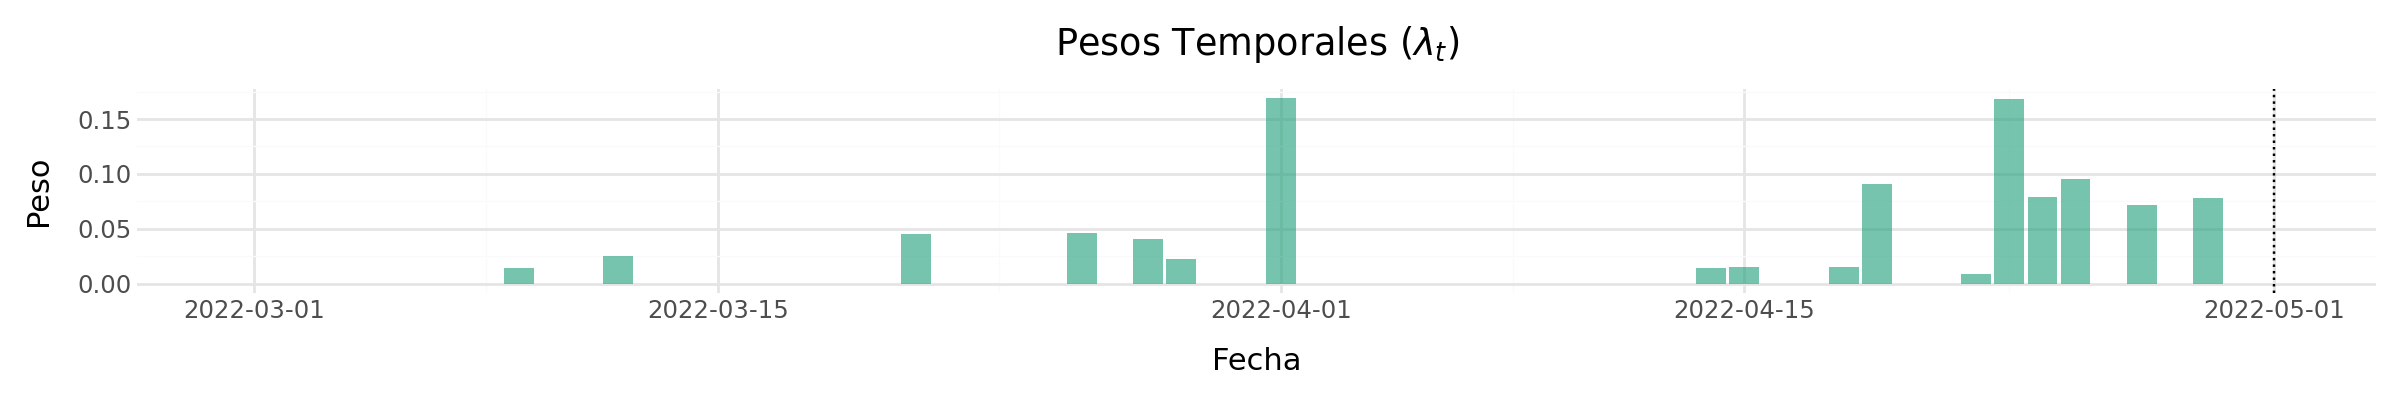

In [165]:
# --- GRÁFICO 2: PESOS TEMPORALES ---
(
    ggplot(time_w, aes(x="date", y="time_weight"))
    + geom_col(fill="#1b9e77", alpha=0.6)
    + geom_vline(xintercept=pd.to_datetime(tr_period), linetype="dotted", color="black")
    + labs(title="Pesos Temporales ($\lambda_t$)", y="Peso", x="Fecha")
    + theme_minimal()
    + theme(figure_size=(12, 2))
)

### Ideas Clave: El Arte del Control Sintético 🧬

Tras explorar la implementación y la teoría detrás del **Control Sintético (SC)** y su evolución hacia el **Synthetic Difference-in-Differences (SDiD)**, aquí tienes los pilares fundamentales que todo maestro de la inferencia causal debe dominar:

#### 1. El Contrafactual como Combinación Lineal
La idea central es que ninguna unidad de control por sí sola es un espejo perfecto de la unidad tratada. Sin embargo, una **combinación ponderada** de "donantes" puede recrear el comportamiento de la unidad tratada en el periodo pre-intervención ($T_{pre}$).
- **Fórmula:** $\hat{Y}_{post, tr}^0 = \sum_{i \in \text{control}} w_i Y_{post, i}$

#### 2. Regresión Horizontal
A diferencia de la regresión clásica donde las filas son individuos, en el SC realizamos una **regresión horizontal**:
- **Filas:** Periodos de tiempo ($t$).
- **Columnas:** Unidades de control ($J$).
- Esto nos permite encontrar los pesos $w$ que mejor minimizan la distancia entre el "gemelo sintético" y el observado durante el entrenamiento.

#### 3. Restricciones de Convexidad (El "Convex Hull")
Para evitar extrapolaciones absurdas (predicciones fuera del rango de los datos), el Control Sintético Canónico impone dos restricciones críticas:
1.  **Suma a la unidad:** $\sum w_i = 1$.
2.  **No negatividad:** $w_i \ge 0$.
Esto asegura que el control sintético sea una **interpolación** de los donantes, ganando interpretabilidad y robustez.

#### 4. Corrección de Sesgo (Debiasing)
Incluso con pesos óptimos, puede existir un sesgo persistente si el control sintético no logra "clonar" perfectamente al tratado en el pasado. El **Debiased SC** utiliza técnicas de *hold-out* (folds) para estimar este sesgo promedio en el pasado y restarlo del efecto estimado en el futuro, refinando el cálculo del $ATT$.

#### 5. Inferencia mediante Folds
Dado que no tenemos una distribución asintótica simple como en OLS, la incertidumbre se estima analizando la variabilidad del efecto entre diferentes bloques de tiempo (*folds*).
- El **Error Estándar ($SE$)** se deriva de la desviación estándar de los ATT calculados en cada fold, permitiéndonos construir intervalos de confianza robustos.

#### 6. Synthetic Difference-in-Differences (SDiD)
Es la frontera final que combina lo mejor de dos mundos:
- **Unit Weights ($w$):** Filtra qué ciudades se parecen más a la tratada.
- **Time Weights ($\lambda$):** Filtra qué momentos del pasado son más predictivos del futuro.
- **Resultado:** Una estimación de **Doble Robustez** que es menos sensible a la elección del periodo de inicio y a la selección de controles.

> **Conclusión Pedagógica:** El Control Sintético no es solo una regresión; es un modelo de **predicción de contrafactuales**. Si puedes predecir con éxito el pasado de una unidad tratada usando a sus vecinos, tu predicción sobre qué habría pasado en el futuro (si no hubiera habido tratamiento) es científicamente creíble.